<a href="https://colab.research.google.com/github/rasikacs23172/ml-practicals-6th-sem/blob/main/mlp9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

mlp9
rasika khante cs23172
aim=To implement the K-means clustering algorithm and analyze the clusturing results using appropriate evaluation techniques

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path="/content/drive/MyDrive/ml data set/Mall_Customers.csv"
df=pd.read_csv(path)
df.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.shape

(200, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
df.isnull()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
195,False,False,False,False,False
196,False,False,False,False,False
197,False,False,False,False,False
198,False,False,False,False,False


In [ ]:
df.isnull().any()

,0
CustomerID,False
Gender,False
Age,False
Annual Income (k$),False
Spending Score (1-100),False


In [ ]:
df.isnull().any().any()

np.False_

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df[df.isnull().any(axis = 1)]

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)


In [ ]:
X = df.iloc[:, [3, 4]].values

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]
 [-1.66266033  1.00159627]
 [-1.62449091 -1.71591298]
 [-1.62449091  1.70038436]
 [-1.58632148 -1.83237767]
 [-1.58632148  0.84631002]
 [-1.58632148 -1.4053405 ]
 [-1.58632148  1.89449216]
 [-1.54815205 -1.36651894]
 [-1.54815205  1.04041783]
 [-1.54815205 -1.44416206]
 [-1.54815205  1.11806095]
 [-1.50998262 -0.59008772]
 [-1.50998262  0.61338066]
 [-1.43364376 -0.82301709]
 [-1.43364376  1.8556706 ]
 [-1.39547433 -0.59008772]
 [-1.39547433  0.88513158]
 [-1.3573049  -1.75473454]
 [-1.3573049   0.88513158]
 [-1.24279661 -1.4053405 ]
 [-1.24279661  1.23452563]
 [-1.24279661 -0.7065524 ]
 [-1.24279661  0.41927286]
 [-1.20462718 -0.74537397]
 [-1.20462718  1.42863343]
 [-1.16645776 -1.7935561 ]
 [-1.16645776  0.88513158]
 [-1.05194947 -1.7935561 ]
 [-1.05194947  1.62274124]
 [-1.05194947 -1.4053405 ]
 [-1.05194947  1.19570407]
 [-1.01378004 -1.28887582]
 

[399.99999999999994, 273.66888662642003, 157.70400815035939, 109.22822707921345, 65.56840815571681, 60.132874871934206, 49.668244837367965, 37.31912287833882, 32.495081199100916, 30.05932269404222]


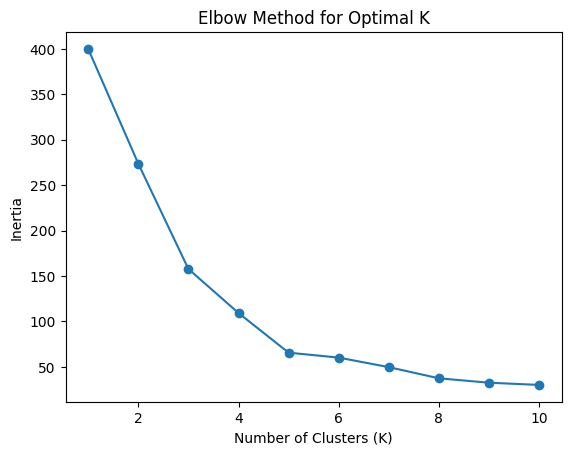

In [ ]:
from IPython.utils.path import random
inertai_values = []

for k in range(1, 11):
  kmeans = KMeans(n_clusters = k, random_state=42)
  kmeans.fit(X_scaled)
  inertai_values.append(kmeans.inertia_)

print(inertai_values)
plt.figure()
plt.plot(range(1, 11), inertai_values, marker = 'o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters = 5, random_state=42)
cluster = kmeans.fit_predict(X_scaled)
df['Cluster']= cluster
print(df.head())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0           1    Male   19                  15                      39        4
1           2    Male   21                  15                      81        2
2           3  Female   20                  16                       6        4
3           4  Female   23                  16                      77        2
4           5  Female   31                  17                      40        4


In [ ]:

print("Inertia :",kmeans.inertia_)

sil_score=silhouette_score(X_scaled,cluster)
print("Silhouette Score :",sil_score)

Inertia : 65.56840815571681
Silhouette Score : 0.5546571631111091


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

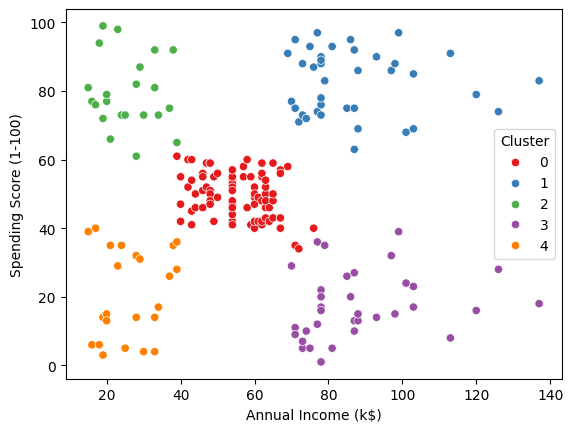

In [ ]:
plt.figure()
sns.scatterplot(x='Annual Income (k$)',y='Spending Score (1-100)',hue='Cluster',data=df, palette='Set1')

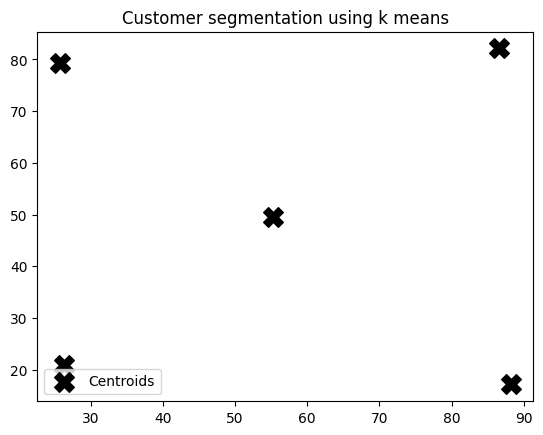

In [ ]:
centroids=scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:,0],centroids[:,1],s=200,c='black',marker='X',label='Centroids')
plt.title('Customer segmentation using k means')
plt.legend()
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=7, random_state=42)
cluster=kmeans.fit_predict(X_scaled)
df['cluster']=cluster
print(df.head())

   CustomerID  Gender  Age  ...  Spending Score (1-100)  Cluster  cluster
0           1    Male   19  ...                      39        4        5
1           2    Male   21  ...                      81        2        2
2           3  Female   20  ...                       6        4        4
3           4  Female   23  ...                      77        2        2
4           5  Female   31  ...                      40        4        5

[5 rows x 7 columns]


In [ ]:
print("Inertia:",kmeans.inertia_)
sil_score=silhouette_score(X_scaled,cluster)
print("Silhouette Score:",sil_score)

Inertia: 49.668244837367965
Silhouette Score: 0.50200146805547


In [ ]:
kmeans = KMeans(n_clusters=8, random_state=42)
cluster=kmeans.fit_predict(X_scaled)
df['cluster']=cluster
print(df.head())

   CustomerID  Gender  Age  ...  Spending Score (1-100)  Cluster  cluster
0           1    Male   19  ...                      39        4        4
1           2    Male   21  ...                      81        2        3
2           3  Female   20  ...                       6        4        4
3           4  Female   23  ...                      77        2        3
4           5  Female   31  ...                      40        4        4

[5 rows x 7 columns]


In [ ]:
print("Inertia:",kmeans.inertia_)
sil_score=silhouette_score(X_scaled,cluster)
print("Silhouette Score:",sil_score)

Inertia: 37.31912287833882
Silhouette Score: 0.4550112502601921
